In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import randint
import seaborn as sns # used for plot interactive graph.
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [2]:
df = pd.read_excel('test.xlsx')

In [3]:
df.head()

,Query Type,Query Subject,Funder,Business Area,Pobal Unit,Business Category,Summary,cleaned,lemmatized
0,FQ - Funder Query,NCS Service Calendar,DCYA,NCS,MAO,Data Analysis - Monitoring/Outputs,"Good morning, \n\nCould we please have the NCS...",could we please have the ncs calendars for an...,ncs calendar service
1,FQ - Funder Query,PAU Confirmation,DCYA,Individual Service Profile,MAO,Data Analysis - Monitoring/Outputs,"Hi , \nHappy New Year – if we can still ...",happy new year – if we can still say that woul...,happy new year able confirm pau email address...
2,EY - Internal EY Query,Extension Grant Scheme - Fee Tables,Internal EY,EYC,MAO,Data Analysis - Monitoring/Outputs,Hi All\n\nI hope you are well. \n\nThe Buildin...,i hope you are well the building blocks exten...,hope building block extension grant applicat...
3,FQ - Funder Query,Funder Queries request - NCS closure days,DCYA,NCS,MAO,Data Analysis - Monitoring/Outputs,The Department is exploring the use of closure...,information specifically required is •\tbased...,information specifically require base ncs pr...
4,FQ - Funder Query,Data request,DCYA,Equal Start,MAO,Data Analysis - Monitoring/Outputs,"Good afternoon, \n\nI would like to request th...",i would like to request the following details...,like request following detail equal start se...


In [4]:
df.columns

Index(['Query Type', 'Query Subject', 'Funder', 'Business Area', 'Pobal Unit',
       'Business Category', 'Summary', 'cleaned', 'lemmatized'],
      dtype='object')

In [5]:
df1= df[['Summary','Pobal Unit']].head(1200)

In [6]:
df1['Pobal Unit'].unique()

array(['MAO', 'FOD', 'CSSD', 'EYYP', 'Corporate Services', 'Better Start',
       'CAR', 'PPD'], dtype=object)

In [7]:
df1['category_id'] = df1['Pobal Unit'].factorize()[0]

In [8]:
category_id_df = df1[['Pobal Unit', 'category_id']].drop_duplicates()
# Dictionaries for future use
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id', 'Pobal Unit']].values)
df1.head()

,Summary,Pobal Unit,category_id
0,"Good morning, \n\nCould we please have the NCS...",MAO,0
1,"Hi Nicole, \nHappy New Year – if we can still ...",MAO,0
2,Hi All\n\nI hope you are well. \n\nThe Buildin...,MAO,0
3,The Department is exploring the use of closure...,MAO,0
4,"Good afternoon, \n\nI would like to request th...",MAO,0


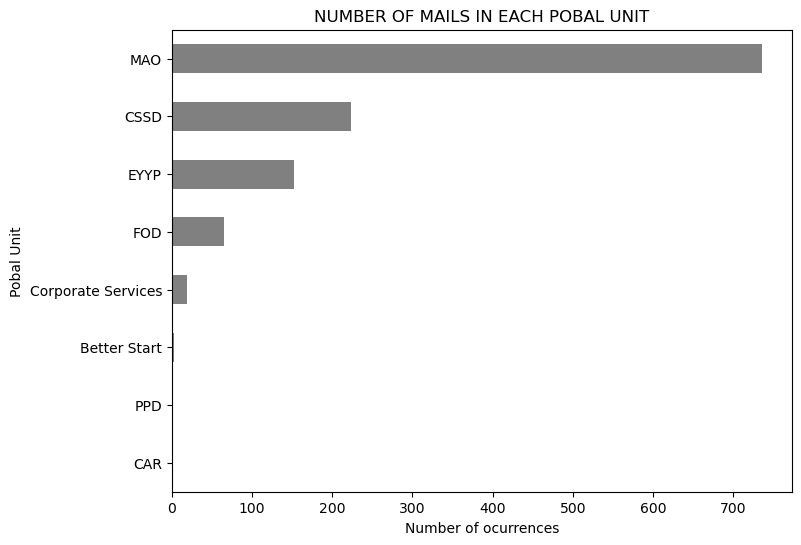

In [9]:
fig = plt.figure(figsize=(8,6))
colors = ['grey','grey','grey','grey','grey','grey','grey','grey','grey',
    'grey','darkblue','darkblue','darkblue']
df1.groupby('Pobal Unit').Summary.count().sort_values().plot.barh(
    ylim=0, color=colors, title= 'NUMBER OF MAILS IN EACH POBAL UNIT')
plt.xlabel('Number of ocurrences', fontsize = 10);

In [10]:
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5,
                        ngram_range=(1, 2), 
                        stop_words='english')
# We transform each complaint into a vector
features = tfidf.fit_transform(df1.Summary).toarray()
labels = df1.category_id
print("Each of the %d mails is represented by %d features (TF-IDF score of unigrams and bigrams)" %(features.shape))

Each of the 1200 mails is represented by 3061 features (TF-IDF score of unigrams and bigrams)


In [11]:
# Finding the three most correlated terms with each of the product categories
N = 3
for Pobal_Unit, category_id in sorted(category_to_id.items()):
  features_chi2 = chi2(features, labels == category_id)
  indices = np.argsort(features_chi2[0])
  feature_names = np.array(tfidf.get_feature_names_out())[indices]
  unigrams = [v for v in feature_names if len(v.split(' ')) == 1]
  bigrams = [v for v in feature_names if len(v.split(' ')) == 2]
  print("n==> %s:" %(Pobal_Unit))
  print("  * Most Correlated Unigrams are: %s" %(', '.join(unigrams[-N:])))
  print("  * Most Correlated Bigrams are: %s" %(', '.join(bigrams[-N:])))

n==> Better Start:
  * Most Correlated Unigrams are: sharon, inspection, fit
  * Most Correlated Bigrams are: building 31, dublin d07, staff member
n==> CAR:
  * Most Correlated Unigrams are: roof, planning, permission
  * Most Correlated Bigrams are: kind regards, good afternoon, relation application
n==> CSSD:
  * Most Correlated Unigrams are: ccif, community, csp
  * Most Correlated Bigrams are: regards karen, regards yvonne, investment fund
n==> Corporate Services:
  * Most Correlated Unigrams are: pob, agencies, public
  * Most Correlated Bigrams are: question ask, rural community, public sector
n==> EYYP:
  * Most Correlated Unigrams are: childcare, history, little
  * Most Correlated Bigrams are: service received, thanks fergal, communication service
n==> FOD:
  * Most Correlated Unigrams are: participants, tús, rss
  * Most Correlated Bigrams are: rss unit, tús rss, advance emer
n==> MAO:
  * Most Correlated Unigrams are: participants, tús, rss
  * Most Correlated Bigrams are: 

In [12]:
X = df1['Summary'] # Collection of documents
y = df1['Pobal Unit'] # Target or the labels we want to predict (i.e., the 13 different complaints of products)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                    random_state = 0)

In [13]:
models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0),
    LinearSVC(),
    MultinomialNB(),
    LogisticRegression(random_state=0),
]
# 5 Cross-validation
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))
entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [14]:
mean_accuracy = cv_df.groupby('model_name').accuracy.mean()
std_accuracy = cv_df.groupby('model_name').accuracy.std()

acc = pd.concat([mean_accuracy, std_accuracy], axis= 1, 
          ignore_index=True)
acc.columns = ['Mean Accuracy', 'Standard deviation']
acc

,Mean Accuracy,Standard deviation
model_name,,
LinearSVC,0.775000,0.031595
LogisticRegression,0.743333,0.016562
MultinomialNB,0.743333,0.020750
RandomForestClassifier,0.653333,0.008015


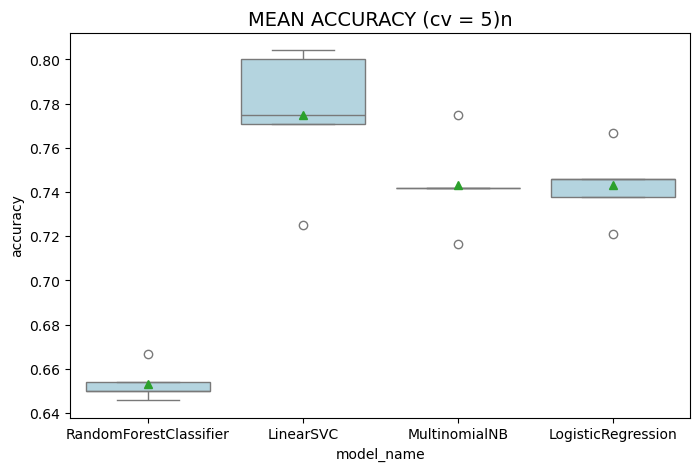

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='model_name', y='accuracy', 
            data=cv_df, 
            color='lightblue', 
            showmeans=True)
plt.title("MEAN ACCURACY (cv = 5)n", size=14);

In [16]:
X_train, X_test, y_train, y_test,indices_train,indices_test = train_test_split(features,labels, df1.index, test_size=0.25,random_state=1)
model = LinearSVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
target_names = df1['Pobal Unit'].unique()
print(f"Target names: {target_names}")
print(f"Number of target names: {len(target_names)}")

Target names: ['MAO' 'FOD' 'CSSD' 'EYYP' 'Corporate Services' 'Better Start' 'CAR' 'PPD']
Number of target names: 8


In [18]:
# Classification report
print('ttttCLASSIFICATIION METRICSn')
print(metrics.classification_report(y_test, y_pred, 
                                    ))

ttttCLASSIFICATIION METRICSn
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       191
           1       0.93      0.72      0.81        18
           2       0.74      0.78      0.76        50
           3       0.43      0.27      0.33        37
           4       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1

    accuracy                           0.77       300
   macro avg       0.49      0.44      0.46       300
weighted avg       0.75      0.77      0.76       300



C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmccann\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

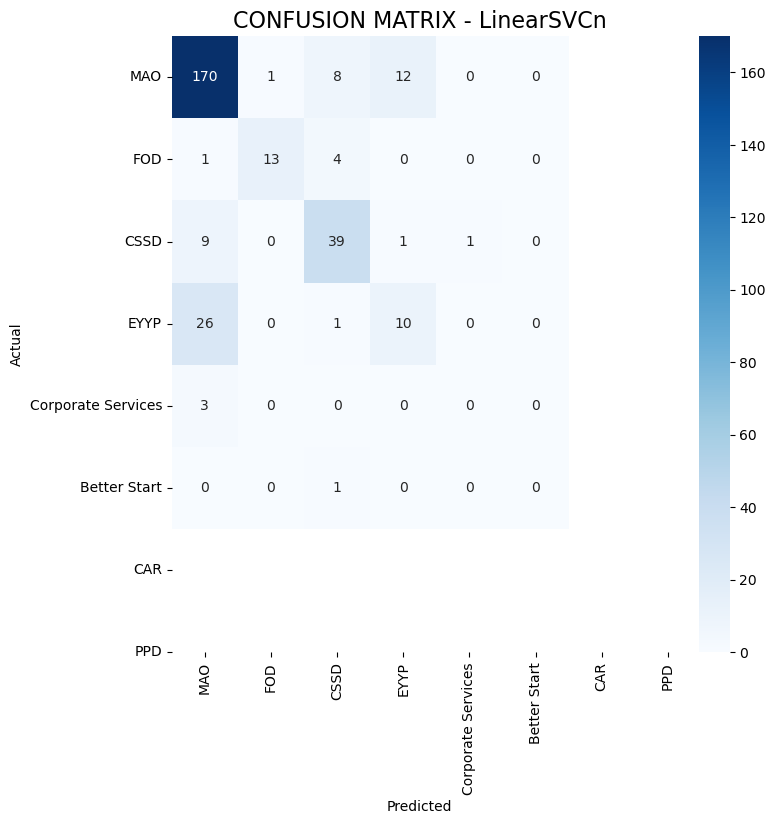

In [19]:
category_id_df.rename(columns = {'Pobal Unit' : 'Pobal_Unit'}, inplace=True)
conf_mat = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt='d',
            xticklabels=category_id_df.Pobal_Unit.values, 
            yticklabels=category_id_df.Pobal_Unit.values)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("CONFUSION MATRIX - LinearSVCn", size=16);

In [20]:
category_id_df.rename(columns = {'Pobal Unit' : 'Pobal_Unit'}, inplace=True)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                    random_state = 0)
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5,
                        ngram_range=(1, 2), 
                        stop_words='english')

fitted_vectorizer = tfidf.fit(X_train)
tfidf_vectorizer_vectors = fitted_vectorizer.transform(X_train)
model = LinearSVC().fit(tfidf_vectorizer_vectors, y_train)

In [22]:
email = "Hi all,As you may be aware AIM Level 7 ********h"
email = print(model.predict(fitted_vectorizer.transform([email])))

['EYYP']


In [23]:
email = "*************************,"

print(model.predict(fitted_vectorizer.transform([email])))

['CSSD']


In [24]:
email = "Hi all We have a PQ request as follows: To ask the Minister for Social Protection the number of individuals applied for fuel allowance in 2023 and 2024, by county; and the number of successful applications there have been in that period in each county.Would it be possible to extract the number of Tús and RSS Fuel Allowance participants who had a fuel entitlement, by county for year ending 2023 and another for 2024."
print(model.predict(fitted_vectorizer.transform([email])))

['FOD']


In [25]:
email = "what services in Louth are currently availing of core funding"
print(model.predict(fitted_vectorizer.transform([email])))

['MAO']


In [26]:
email = 'how many comunity centre funding schemes have been taken up in 2010'
print(model.predict(fitted_vectorizer.transform([email])))

['MAO']


In [27]:
email = 'Hi All, Hope all is good in Pobal. will be presenting on SICAP at the *****************'
print(model.predict(fitted_vectorizer.transform([email])))


['MAO']


In [28]:
email = "Hi all Please provide a list of participants & supervisors who are currently on Tús with ***********.  Please include their placement provider details, start date etc.********"
print(model.predict(fitted_vectorizer.transform([email])))


['FOD']


In [29]:
email = "Could we have the number of NCS beneficiaries that are in families of 3 children or more where the children are aged:a)	1 – 12 yearsb)	1 – 14 years"
print(model.predict(fitted_vectorizer.transform([email])))

['MAO']


In [30]:
email = "Hello,We received correspondence on******************************************************* Ltd looking for entry into the CSP Programme.We issued correspondence 25/09/2024 outlining the situation and this Monday we sent a letter to say their application would not be reviewed until Budget 2026  is announced. I’m just wondering if there has been any correspondence between Pobal and this organisation since 25/09/2024.Thank you.Kind Regards,********************* "
print(model.predict(fitted_vectorizer.transform([email])))

['CSSD']


In [31]:
email = "Hello,How many children in the NCS 2025? "
print(model.predict(fitted_vectorizer.transform([email])))

['MAO']
